https://github.com/FabricioArendTorres/FlowConductor/tree/main

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt

from msi.gaussian_mixture.likelihood_gmm import LikelihoodGMM
from msi.utils import preprocessing
from msfm.utils import prior, parameters, files, logger

24-01-26 08:20:37   imports.py INF   Setting up healpy to run on 32 CPUs 


# load network predictions

### v4

In [3]:
# # combined probes
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v4"

# # all parameters
# model_dir = "2023-08-31_03-29-47_resnet_vanilla"

# n_steps = 20000
# params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]

### v6

#### lensing only

In [4]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing_only"

# delta loss
# model_dir = "delta/2024-01-12_19-35-59_resnet_vanilla"

# likelihood loss
model_dir = "likelihood/2024-01-22_05-29-26_resnet_vanilla"

n_steps = 80000
params = ["Om", "s8", "w0", "Aia", "n_Aia"]

#### clustering only

#### combined probes

### general

In [5]:
# dataset
fidu_preds, grid_preds, grid_cosmos, file_dict = preprocessing.get_reshaped_network_preds(
    base_dir, model_dir, n_steps, n_params=len(params)
)

# output directory and file names
out_dir = os.path.join(base_dir, model_dir)
label = f"{n_steps}_gmm"

24-01-26 08:20:40 input_output INF   Array shapes: 
24-01-26 08:20:40 input_output INF   fiducial/vali/pred = (4, 20) 
24-01-26 08:20:40 input_output INF   fiducial/vali/i_example = (4,) 
24-01-26 08:20:40 input_output INF   fiducial/vali/i_noise = (4,) 
24-01-26 08:20:40 input_output INF   grid/pred          = (2500, 48, 20) 
24-01-26 08:20:40 input_output INF   grid/cosmo         = (2500, 5) 
24-01-26 08:20:40 input_output INF   grid/i_example     = (2500, 48) 
24-01-26 08:20:40 input_output INF   grid/i_noise       = (2500, 48) 
24-01-26 08:20:40 input_output INF   grid/i_sobol       = (2500,) 


24-01-26 08:20:40 preprocessin INF   Shapes after concatenation and selection: 
24-01-26 08:20:40 preprocessin INF   fidu_preds  = (4, 5) 
24-01-26 08:20:40 preprocessin INF   grid_preds  = (120000, 5) 
24-01-26 08:20:40 preprocessin INF   grid_cosmos = (120000, 5) 


# Gaussian Mixture Model $p(x|\theta)$

### architecture

In [6]:
model = LikelihoodGMM(
    params, 
    conf, 
    out_dir=out_dir, 
    label=label
)

24-01-26 08:20:40 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/run_files/v6/lensing_only/likelihood/2024-01-22_05-29-26_resnet_vanilla/80000_gmm/likelihood_gmm 
24-01-26 08:20:40 likelihood_g WAR   Assuming that the feature/summary dimension is equal to the context/parameter dimension 
24-01-26 08:20:40 likelihood_g INF   Using the default Gaussian mixture model 
24-01-26 08:20:41 likelihood_g INF   Loaded the model from /pscratch/sd/a/athomsen/run_files/v6/lensing_only/likelihood/2024-01-22_05-29-26_resnet_vanilla/80000_gmm/likelihood_gmm 


### load existing

In [7]:
# # load a pretrained flow
# flow = LikelihoodFlow.load(
#     os.path.join(base_dir, model_dir, f"model{n_steps}_flow.pt")
# )

### training

24-01-26 08:20:42 likelihood_g INF   Fitted the x and y scalers 


epoch:  10%|█         | 101/1000 [00:10<00:52, 17.19it/s, loss=-16, val_loss=-14.8, lr=1.78e-5]  

Restoring model weights from the end of the best epoch: 2.


epoch:  10%|█         | 102/1000 [00:10<00:52, 17.19it/s, loss=-16, val_loss=-14.8, lr=1.78e-5]

Epoch 102: early stopping


epoch:  10%|█         | 102/1000 [00:10<01:29, 10.04it/s, loss=-16, val_loss=-14.8, lr=1.78e-5]


24-01-26 08:20:53 likelihood_g INF   Saved the model to /pscratch/sd/a/athomsen/run_files/v6/lensing_only/likelihood/2024-01-22_05-29-26_resnet_vanilla/80000_gmm/likelihood_gmm/likelihood_gmm.tf 


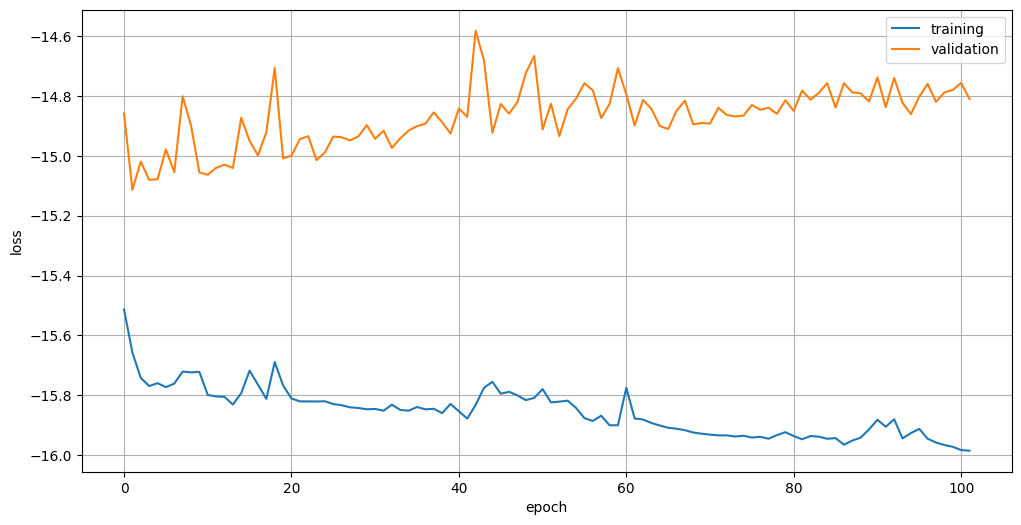

In [8]:
model.fit(
    x=grid_preds,
    theta=grid_cosmos,
    n_epochs=1000,
    # dataset
    batch_size=10000,
    vali_split=0.1,
    # optimizer
    learning_rate=1e-3,
    weight_decay=0.0,
    clip_by_global_norm=1.0,
    learning_rate_min=1e-6,
    # early stopping
    n_patience_epochs=100,
    min_delta=0.01,
    save_model=True,
)

### convergence tests

In [9]:
temp = model.sample_likelihood(
    theta=file_dict["grid/cosmo"],
    n_samples=100
)

100%|████████████████████████████|   | 1/1 [00:00<00:00,  8.09it/s]           drawing samples with batch_size=10000


24-01-26 08:20:53 likelihood_b INF   Drawing samples from the likelihood 
100%|████████████████████████████|   | 1/1 [00:00<00:00,  1.58it/s]           drawing samples with batch_size=10000
24-01-26 08:20:54 likelihood_b INF   Done drawing samples after 0:00:00.66 
100%|████████████████████████████|   | 2500/2500 [00:00<00:00, 7787.37it/s]   EECP: looping through cosmos
24-01-26 08:21:06 diagnostics. INF   TARP random reference points: Using an independent uniform distribution 
100%|████████████████████████████|   | 48/48 [00:04<00:00, 10.01it/s]         TARP: looping through examples


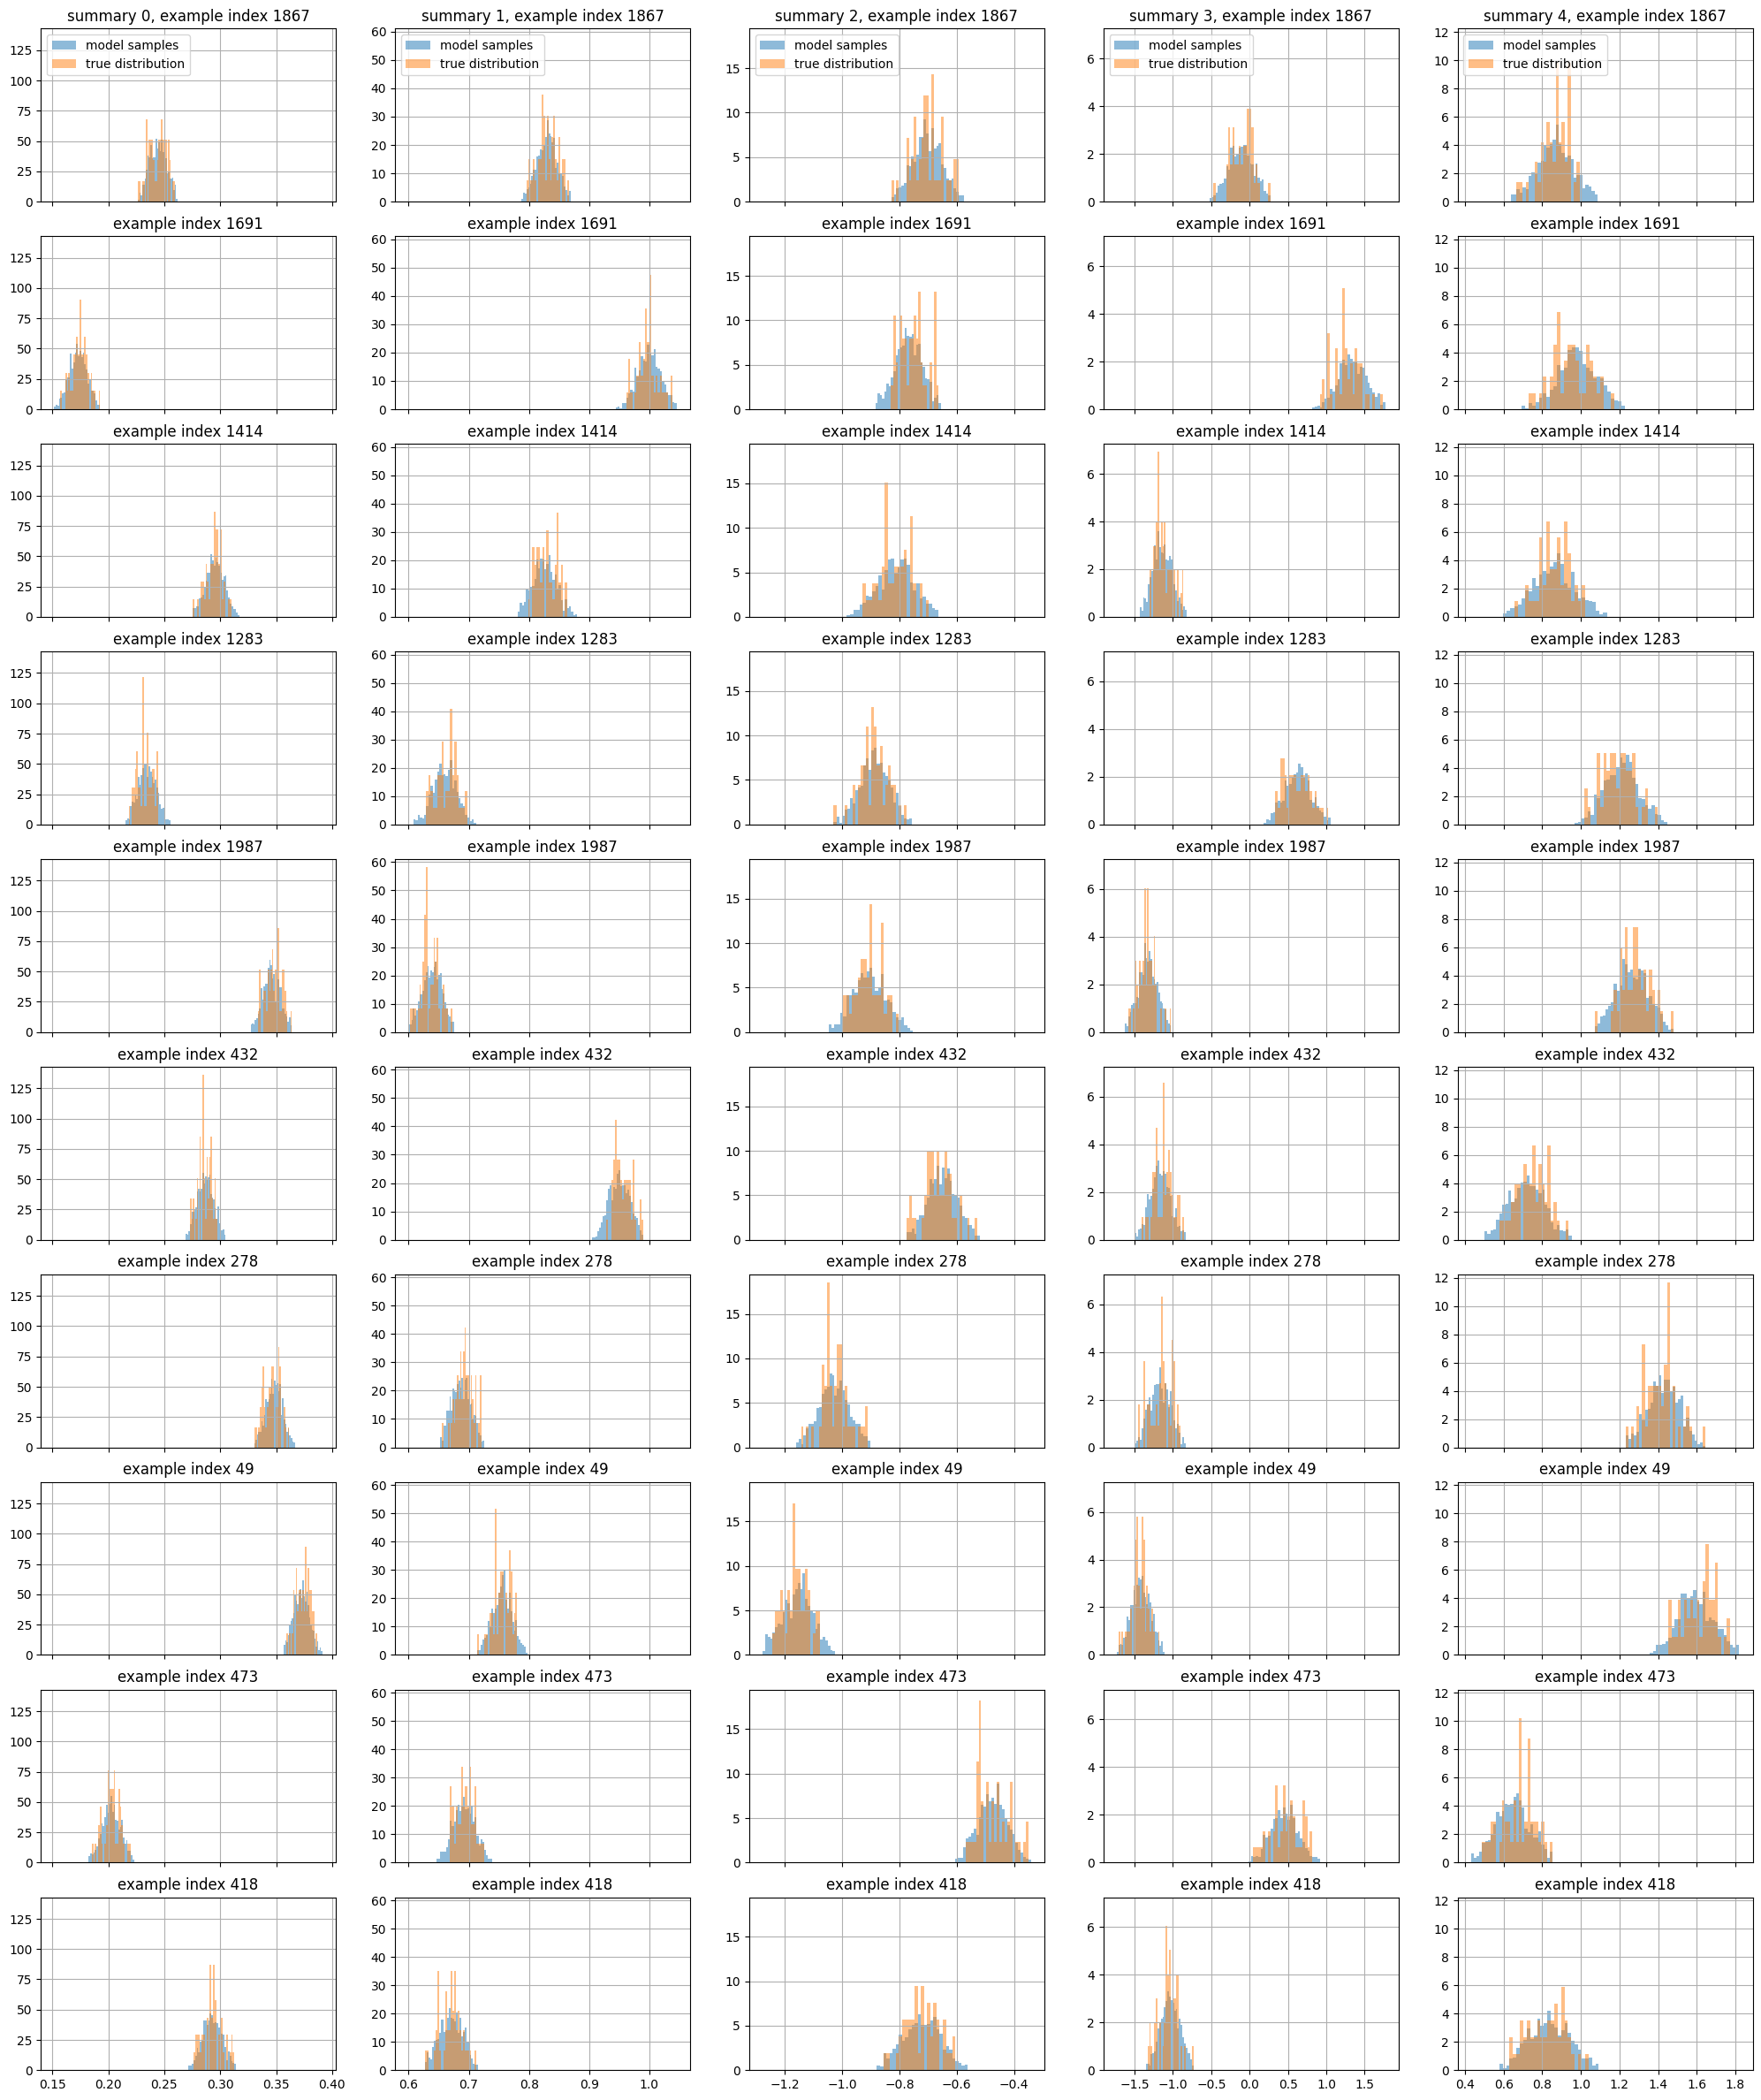

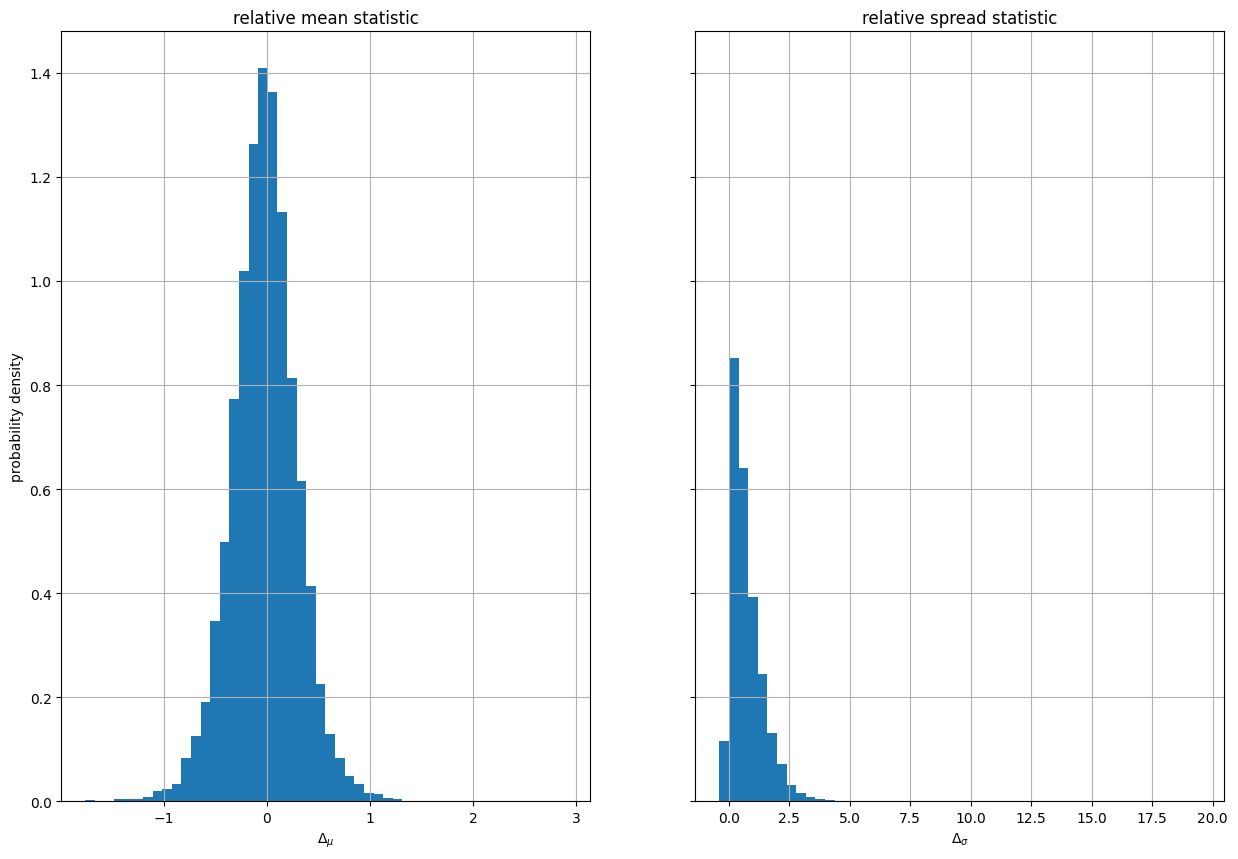

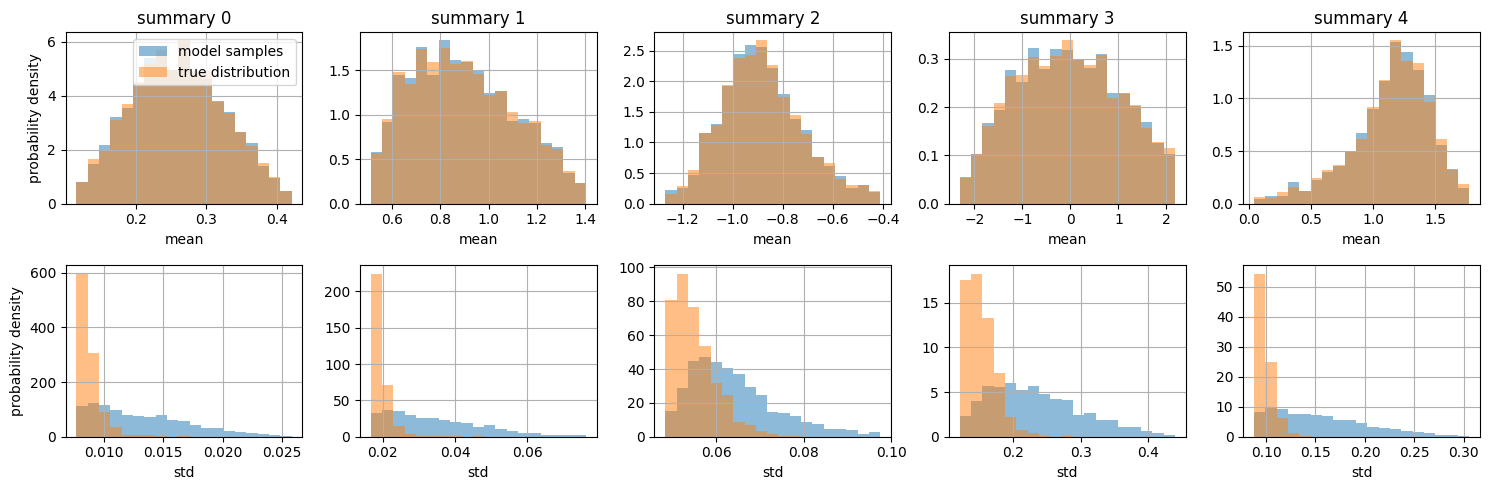

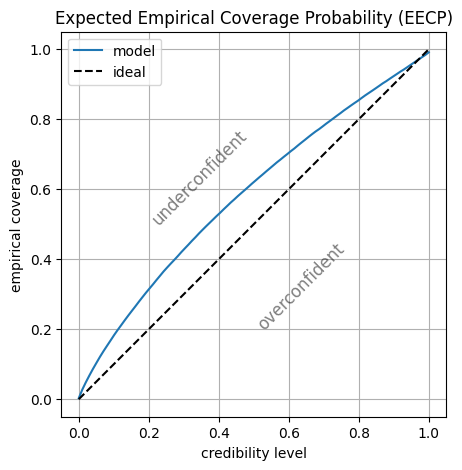

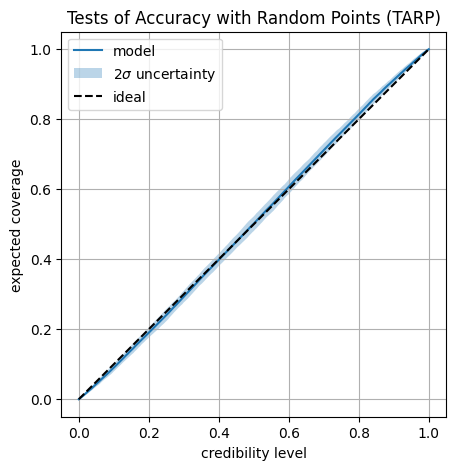

In [10]:
grid_preds_sample = model.plot_diagnostics(
    # these must be the raw arrays where the cosmo and example axis are still separate
    grid_preds_true=file_dict["grid/pred"][...,:len(params)], 
    grid_cosmos=file_dict["grid/cosmo"],
    n_samples=1000,
    do_hist=True,
    do_dlss=True,
    do_eecp=True,
    do_tarp=True,
    tarp_kwargs={"reference_dist": "uniform", "reference_scale": 1, "reference_dependence": False},
)

### observation

In [11]:
i_obs = 0
# i_obs = np.argmin(np.sum(np.square(np.median(fidu_preds, axis=0, keepdims=True) - fidu_preds), axis=-1))

print(f"Using the example index {i_obs}")
obs_pred = fidu_preds[i_obs]

Using the example index 0


### MCMC

In [12]:
posterior_samples = model.sample_posterior(
    obs_pred,
)

24-01-26 08:21:21      mcmc.py INF   Initial values in prior: True 
24-01-26 08:21:21      mcmc.py INF   Starting the burn in MCMC chain (100 steps) 
24-01-26 08:21:34      mcmc.py INF   Starting the main MCMC chain (500 steps) 


100%|██████████| 500/500 [01:02<00:00,  8.00it/s]

24-01-26 08:22:36      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v6/lensing_only/likelihood/2024-01-22_05-29-26_resnet_vanilla/80000_gmm/likelihood_gmm/chain.npy 


### plotting

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

24-01-26 08:22:41  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v6/lensing_only/likelihood/2024-01-22_05-29-26_resnet_vanilla/80000_gmm/likelihood_gmm/contours.png 


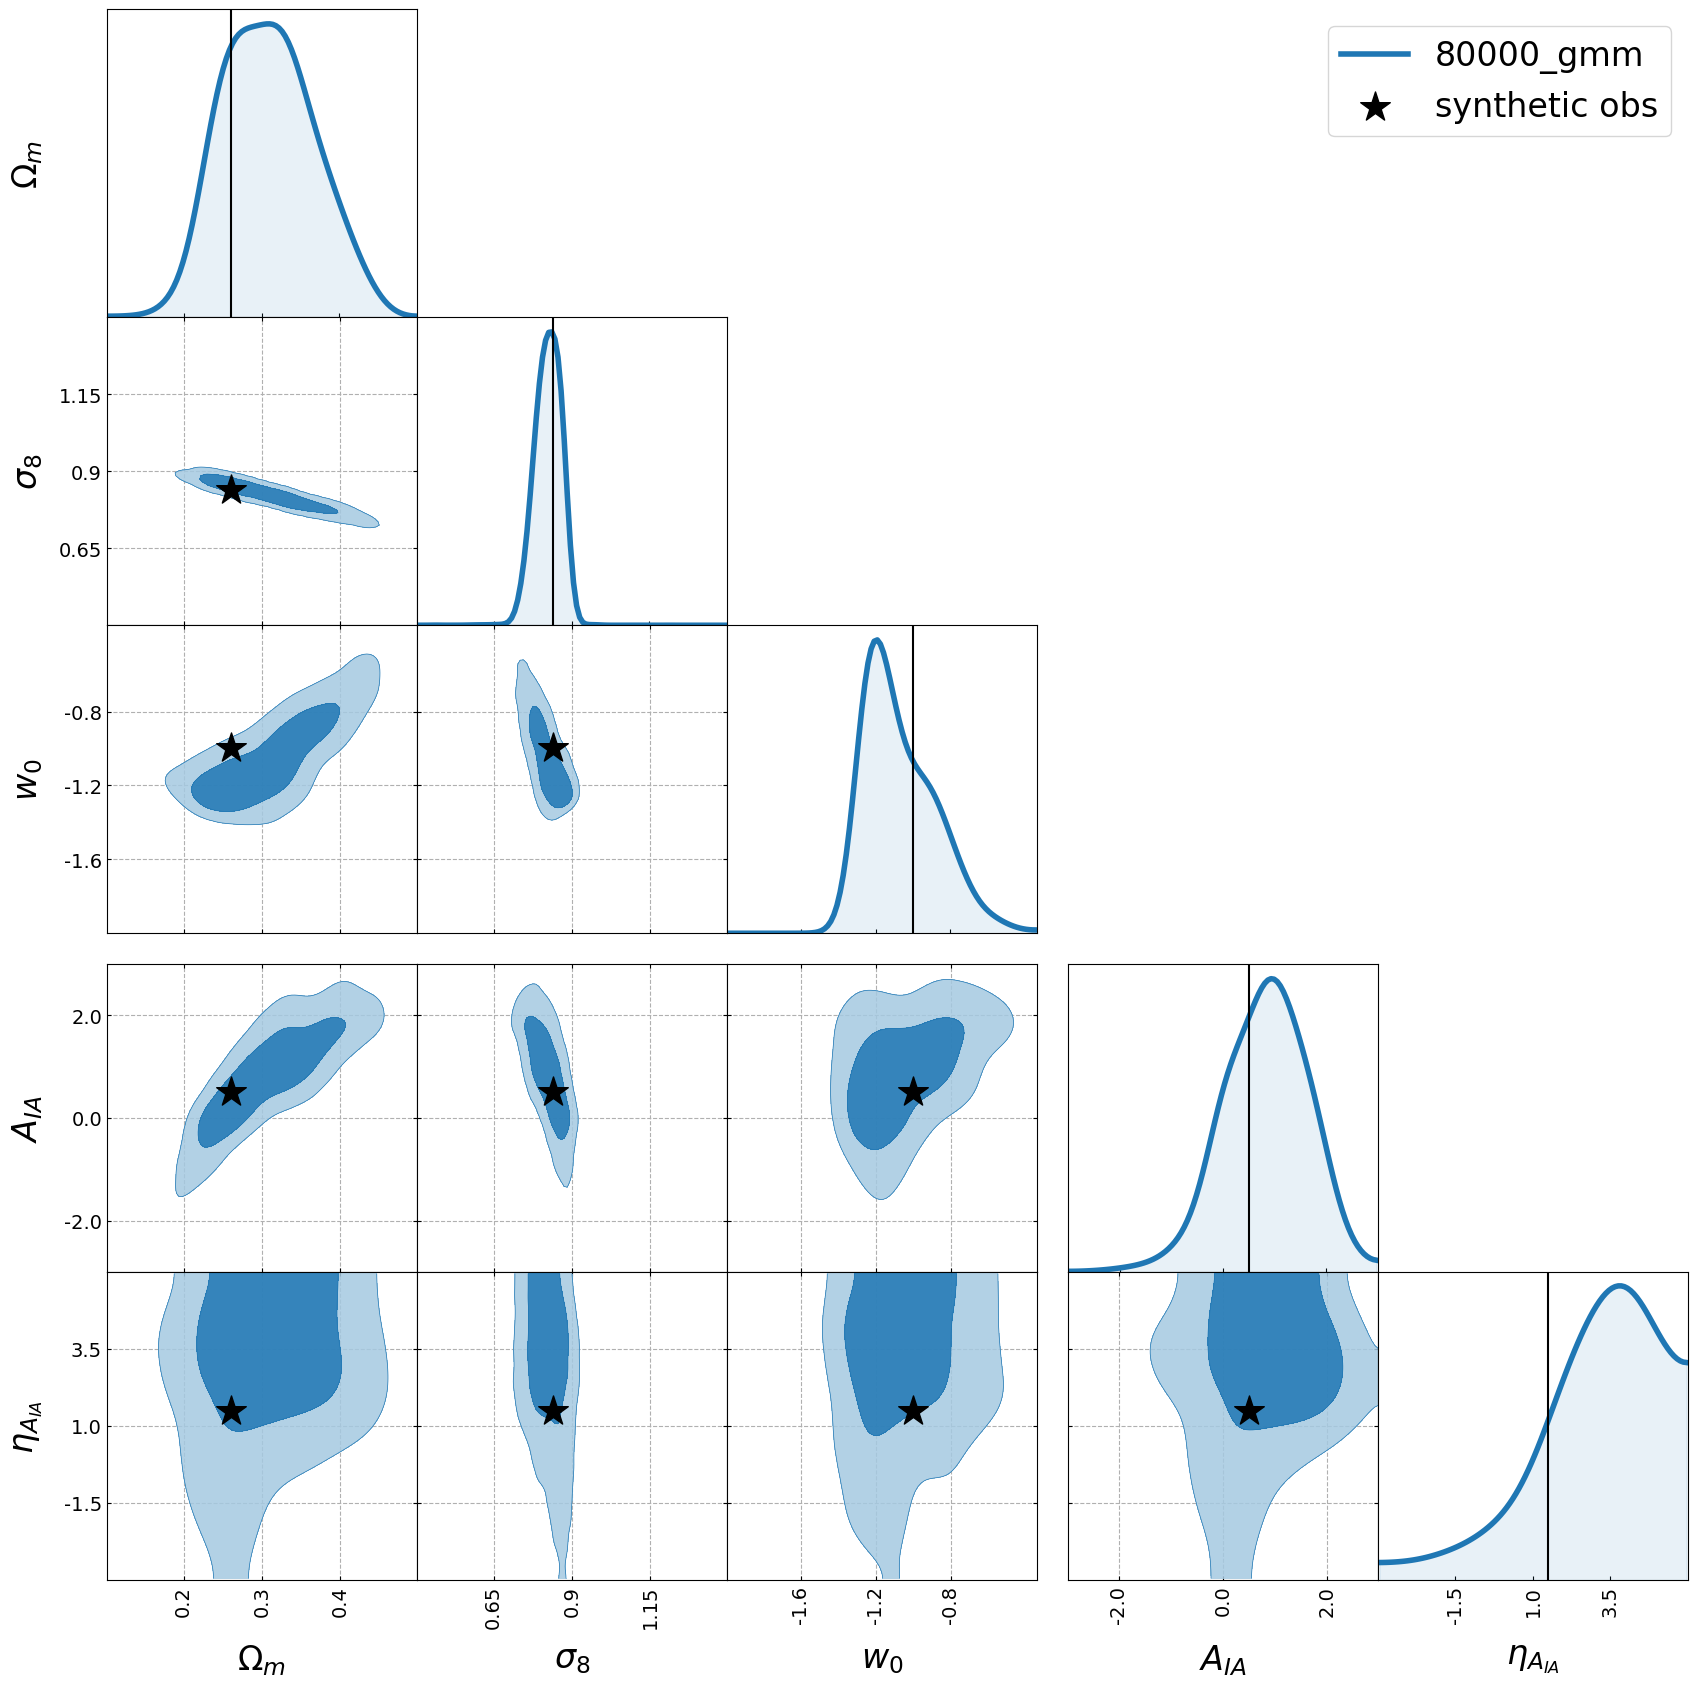

In [13]:
model.plot_contours(
    posterior_samples,
)